In [63]:
# 📦 Install dependencies
!pip install -q timm torch torchvision torchaudio kaggle onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 14.5 MB/s eta 0:00:00


In [64]:

# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from google.colab import drive, files
import os
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import json
import timm
import onnxscript

In [36]:

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 📁 Mount Google Drive
drive.mount('/content/drive')


Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:

# =============================================================================
# 🎯 CONFIGURASI PATH
# =============================================================================
PROJECT_PATH = Path('/content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1')
DATASET_PATH = PROJECT_PATH / 'dataset'
MODEL_SAVE_PATH = PROJECT_PATH / 'models'
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"📂 Project path: {PROJECT_PATH}")
print(f"📂 Dataset path: {DATASET_PATH}")
print(f"📂 Models path: {MODEL_SAVE_PATH}")


📂 Project path: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1
📂 Dataset path: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset
📂 Models path: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/models


In [39]:

# =============================================================================
# 🔐 KAGLE AUTHENTICATION
# =============================================================================
KAGGLE_JSON_PATH = Path('/root/.kaggle/kaggle.json')

if not KAGGLE_JSON_PATH.exists():
    print("⚠️ Kaggle API token tidak ditemukan!")
    print("Silakan upload kaggle.json di bawah ini:\n")
    files.upload()

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle token berhasil di-setup!\n")
else:
    print("✅ Kaggle API token sudah ada!\n")


✅ Kaggle API token sudah ada!



### Struktur folder yang diharapkan:
### drowsiness_dataset/
###   ├── mengantuk/
###   │   ├── img1.jpg
###   │   └── img2.jpg
###   └── tidak_mengantuk/
###       ├── img1.jpg
###       └── img2.jpg

In [40]:

# =============================================================================
# ⬇️ DOWNLOAD & EXTRACT DATASET
# =============================================================================
dataset_zip = PROJECT_PATH / 'driver-drowsiness-dataset-ddd.zip'
extracted_folder = DATASET_PATH / 'DDD'

if not extracted_folder.exists():
    print("⬇️ Downloading dataset dari Kaggle...")
    !kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd -p "{PROJECT_PATH}"

    if dataset_zip.exists():
        print("📦 Extracting dataset...")
        with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
            zip_ref.extractall(DATASET_PATH)

        # Hapus zip file setelah extract (opsional)
        dataset_zip.unlink(missing_ok=True)
        print("✅ Dataset berhasil diekstrak!\n")
    else:
        print("❌ Download gagal atau file tidak ditemukan!")
else:
    print("✅ Dataset sudah ada, skip download!\n")


⬇️ Downloading dataset dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
 99% 2.57G/2.58G [00:18<00:00, 223MB/s]
100% 2.58G/2.58G [00:18<00:00, 147MB/s]
📦 Extracting dataset...
✅ Dataset berhasil diekstrak!



In [41]:

# =============================================================================
# 🔍 DEBUGGING: CEK STRUKTUR FOLDER
# =============================================================================
print("🔍 DEBUGGING: Mencari folder Drowsy dan Non Drowsy...")
print(f"Isi folder {DATASET_PATH}:")
!ls -la "{DATASET_PATH}"

# Cari folder secara rekursif jika perlu
def find_folders(root_path, folder_names=['Drowsy', 'Non Drowsy']):
    """Cari folder secara rekursif"""
    found_paths = {}
    root_path = Path(root_path)

    for folder_name in folder_names:
        # Cari di semua subfolder
        matches = list(root_path.rglob(folder_name))
        if matches:
            found_paths[folder_name] = matches[0]  # Ambil yang pertama
        else:
            found_paths[folder_name] = None

    return found_paths

folder_paths = find_folders(DATASET_PATH)
print("\n📂 Folder ditemukan:")
for name, path in folder_paths.items():
    print(f"  {name}: {path}")


🔍 DEBUGGING: Mencari folder Drowsy dan Non Drowsy...
Isi folder /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset:
total 4
drwx------ 4 root root 4096 Jan 25 09:09 'Driver Drowsiness Dataset (DDD)'

📂 Folder ditemukan:
  Drowsy: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset/Driver Drowsiness Dataset (DDD)/Drowsy
  Non Drowsy: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset/Driver Drowsiness Dataset (DDD)/Non Drowsy


In [42]:

# =============================================================================
# 🔧 DATASET CLASS
# =============================================================================
class DrowsinessDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
        except Exception as e:
            print(f"⚠️ Error loading {img_path}: {e}")
            image = torch.zeros(3, 224, 224)  # Dummy data

        label = self.labels[idx]
        return image, label


In [43]:

# =============================================================================
# 📊 DATA PREPROCESSING
# =============================================================================
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

# =============================================================================
# 📂 LOAD DATASET
# =============================================================================
def load_dataset():
    # Gunakan folder yang sudah ditemukan sebelumnya
    drowsy_path = folder_paths.get('Drowsy')
    non_drowsy_path = folder_paths.get('Non Drowsy')

    if not drowsy_path:
        raise FileNotFoundError(f"❌ Folder 'Drowsy' tidak ditemukan di {DATASET_PATH}")
    if not non_drowsy_path:
        raise FileNotFoundError(f"❌ Folder 'Non Drowsy' tidak ditemukan di {DATASET_PATH}")

    print(f"✅ Menggunakan folder:")
    print(f"   Drowsy: {drowsy_path}")
    print(f"   Non Drowsy: {non_drowsy_path}")

    # Get semua gambar
    drowsy_images = list(drowsy_path.glob('*.jpg')) + list(drowsy_path.glob('*.png')) + list(drowsy_path.glob('*.jpeg'))
    non_drowsy_images = list(non_drowsy_path.glob('*.jpg')) + list(non_drowsy_path.glob('*.png')) + list(non_drowsy_path.glob('*.jpeg'))

    print(f"📊 Jumlah gambar ditemukan:")
    print(f"   Drowsy: {len(drowsy_images)}")
    print(f"   Non-Drowsy: {len(non_drowsy_images)}")

    if len(drowsy_images) == 0 or len(non_drowsy_images) == 0:
        raise FileNotFoundError("❌ Tidak ada gambar yang ditemukan!")

    all_images = drowsy_images + non_drowsy_images
    all_labels = [1] * len(drowsy_images) + [0] * len(non_drowsy_images)

    # Split data (80% train, 20% val)
    return train_test_split(all_images, all_labels, test_size=0.2,
                          random_state=42, stratify=all_labels)

# Split data
train_images, val_images, train_labels, val_labels = load_dataset()
train_transform, val_transform = get_transforms()

train_dataset = DrowsinessDataset(train_images, train_labels, train_transform)
val_dataset = DrowsinessDataset(val_images, val_labels, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"\n✅ Data loaded:")
print(f"   Train: {len(train_dataset)} images")
print(f"   Val: {len(val_dataset)} images")
print(f"   Batch size: 32")


✅ Menggunakan folder:
   Drowsy: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset/Driver Drowsiness Dataset (DDD)/Drowsy
   Non Drowsy: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset/Driver Drowsiness Dataset (DDD)/Non Drowsy
📊 Jumlah gambar ditemukan:
   Drowsy: 22348
   Non-Drowsy: 19445

✅ Data loaded:
   Train: 33434 images
   Val: 8359 images
   Batch size: 32


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [53]:
# Jalankan cell ini untuk debug
import timm

# Lihat semua model mobilevitv2
print("📋 Semua model MobileViTv2 tersedia:")
all_models = timm.list_models('mobilevitv2*', pretrained=True)
for m in all_models:
    print(f"  - {m}")

# Cek pretrained tags untuk mobilevitv2_100
print("\n🔍 Detail pretrained untuk mobilevitv2_100:")
try:
    cfg = timm.models.get_pretrained_cfg('mobilevitv2_100')
    if cfg:
        print(cfg)
except:
    print("❌ Tidak ada detail pretrained khusus, gunakan nama dasar saja")

📋 Semua model MobileViTv2 tersedia:
  - mobilevitv2_050.cvnets_in1k
  - mobilevitv2_075.cvnets_in1k
  - mobilevitv2_100.cvnets_in1k
  - mobilevitv2_125.cvnets_in1k
  - mobilevitv2_150.cvnets_in1k
  - mobilevitv2_150.cvnets_in22k_ft_in1k
  - mobilevitv2_150.cvnets_in22k_ft_in1k_384
  - mobilevitv2_175.cvnets_in1k
  - mobilevitv2_175.cvnets_in22k_ft_in1k
  - mobilevitv2_175.cvnets_in22k_ft_in1k_384
  - mobilevitv2_200.cvnets_in1k
  - mobilevitv2_200.cvnets_in22k_ft_in1k
  - mobilevitv2_200.cvnets_in22k_ft_in1k_384

🔍 Detail pretrained untuk mobilevitv2_100:
PretrainedCfg(url='', file=None, state_dict=None, hf_hub_id='timm/mobilevitv2_100.cvnets_in1k', hf_hub_filename=None, source=None, architecture='mobilevitv2_100', tag='cvnets_in1k', custom_load=False, input_size=(3, 256, 256), test_input_size=None, min_input_size=None, fixed_input_size=False, interpolation='bicubic', crop_pct=0.888, test_crop_pct=None, crop_mode='center', mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), num_classes=1000, la

In [56]:
# =============================================================================
# 🏗️ MODEL SETUP (MobileViTv2-100) - VERSI FIX
# =============================================================================

# Pilihan model yang valid (pilih SALAH SATU):
MODEL_NAME = 'mobilevitv2_100'  # ✅ Paling aman, default pretrained
# MODEL_NAME = 'mobilevitv2_100.cvnets_in1k'  # Alternatif dengan tag spesifik
# MODEL_NAME = 'mobilevitv2_050'  # Versi lebih kecil & cepat

print(f"📦 Loading model: {MODEL_NAME}")

# Buat model
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=2).to(device)

print(f"✅ Model loaded successfully!")
print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

📦 Loading model: mobilevitv2_100
✅ Model loaded successfully!
📊 Model parameters: 4,389,867


In [57]:
# =============================================================================
# 🚀 TRAINING LOOP
# =============================================================================
def train_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), 100 * correct / total

def validate_epoch(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), 100 * correct / total

# Train
best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"\n{'='*60}")
print(f"🚀 STARTING TRAINING")
print(f"{'='*60}\n")

for epoch in range(20):
    print(f"\nEpoch {epoch+1}/20")
    print("-" * 40)

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train: {train_loss:.4f} loss, {train_acc:.2f}% acc")
    print(f"Val:   {val_loss:.4f} loss, {val_acc:.2f}% acc")

    if val_acc > best_acc:
        best_acc = val_acc
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'class_names': ['Non Drowsy', 'Drowsy']
        }
        torch.save(checkpoint, MODEL_SAVE_PATH / 'best_model.pth')
        print(f"⭐ New best model saved: {best_acc:.2f}%")

print(f"\n{'='*60}")
print(f"✅ TRAINING COMPLETE! Best Acc: {best_acc:.2f}%")
print(f"{'='*60}\n")



🚀 STARTING TRAINING


Epoch 1/20
----------------------------------------


Training:   0%|          | 0/1045 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Validation: 100%|██████████| 262/262 [01:02<00:00,  4.21it/s]


Train: 0.0592 loss, 98.26% acc
Val:   0.0074 loss, 99.70% acc
⭐ New best model saved: 99.70%

Epoch 2/20
----------------------------------------


Validation: 100%|██████████| 262/262 [01:02<00:00,  4.17it/s]


Train: 0.0030 loss, 99.94% acc
Val:   0.0022 loss, 99.94% acc
⭐ New best model saved: 99.94%

Epoch 3/20
----------------------------------------


...

Train: 0.0000 loss, 100.00% acc
Val:   0.0000 loss, 100.00% acc

Epoch 19/20
----------------------------------------


Validation: 100%|██████████| 262/262 [00:55<00:00,  4.73it/s]


Train: 0.0001 loss, 100.00% acc
Val:   0.0000 loss, 100.00% acc

Epoch 20/20
----------------------------------------


Validation: 100%|██████████| 262/262 [00:54<00:00,  4.82it/s]

Train: 0.0003 loss, 100.00% acc
Val:   0.0000 loss, 100.00% acc

✅ TRAINING COMPLETE! Best Acc: 100.00%



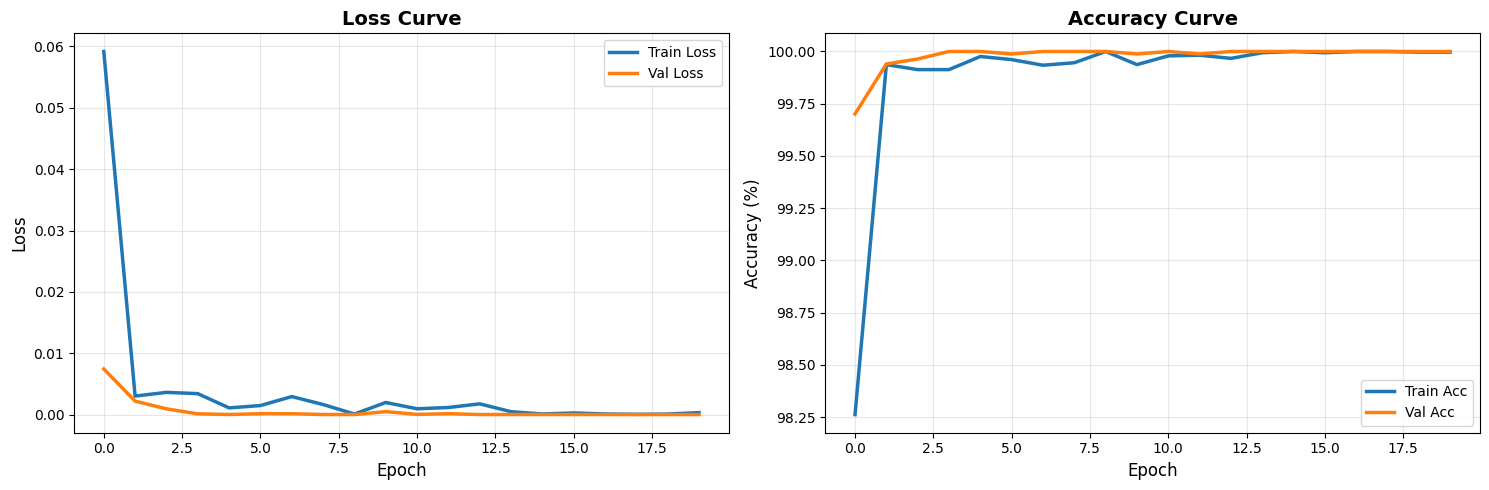

In [58]:

# =============================================================================
# 📊 PLOT HISTORY (SAVE DI DALAM FOLDER PROJECT)
# =============================================================================
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2.5)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2.5)
    ax1.set_title('Loss Curve', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2.5)
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2.5)
    ax2.set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    # SAVE DI DALAM FOLDER PROJECT
    plt.savefig(PROJECT_PATH / 'training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)


In [65]:

# =============================================================================
# 💾 EXPORT MODEL
# =============================================================================
print("\n📦 Exporting models...")

# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# 1. PyTorch model
torch.save(model.state_dict(), MODEL_SAVE_PATH / 'drowsiness_mobilevitv2.pth')
print("✅ PyTorch model saved")

# 2. ONNX model
dummy_input = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(model, dummy_input, MODEL_SAVE_PATH / 'model.onnx',
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}})
print("✅ ONNX model saved")

# 3. Class names
with open(MODEL_SAVE_PATH / 'classes.json', 'w') as f:
    json.dump(checkpoint['class_names'], f)
print("✅ Class names saved")



📦 Exporting models...
✅ PyTorch model saved


/tmp/ipython-input-307278397.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy_input, MODEL_SAVE_PATH / 'model.onnx',


[torch.onnx] Obtain model graph for `ByobNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ByobNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 65 of general pattern rewrite rules.
✅ ONNX model saved
✅ Class names saved


In [66]:

# =============================================================================
# 📋 FINAL SUMMARY
# =============================================================================
print(f"\n{'='*60}")
print(f"📁 SEMUA FILE TERSIMPAN DI:")
print(f"{'='*60}")
print(f"📂 Project root: {PROJECT_PATH}")
print(f"📂 Dataset:      {DATASET_PATH}/DDD/")
print(f"📂 Models:       {MODEL_SAVE_PATH}/")
print(f"📂 History:      {PROJECT_PATH}/training_history.png")
print(f"{'='*60}")
print("\n📂 Struktur lengkap:")
!ls -lh "{PROJECT_PATH}"
print(f"\n📂 Detail models:")
!ls -lh "{MODEL_SAVE_PATH}"
print(f"{'='*60}\n")


📁 SEMUA FILE TERSIMPAN DI:
📂 Project root: /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1
📂 Dataset:      /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/dataset/DDD/
📂 Models:       /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/models/
📂 History:      /content/drive/MyDrive/Capstone Project/Test & Train Drowiness V1/training_history.png

📂 Struktur lengkap:
total 101K
drwx------ 3 root root 4.0K Jan 25 09:05 dataset
drwx------ 2 root root 4.0K Jan 25 11:57 models
-rw------- 1 root root  93K Jan 25 11:54 training_history.png

📂 Detail models:
total 52M
-rw------- 1 root root  17M Jan 25 09:56 best_model.pth
-rw------- 1 root root   24 Jan 25 11:57 classes.json
-rw------- 1 root root  17M Jan 25 11:57 drowsiness_mobilevitv2.pth
-rw------- 1 root root 762K Jan 25 11:57 model.onnx
-rw------- 1 root root  17M Jan 25 11:57 model.onnx.data

